<a href="https://colab.research.google.com/github/maheshisewwandisamaraweera/image-authentication-project/blob/maheshi/notebooks/Module_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
import numpy as np
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

In [3]:
model_path = "/content/drive/MyDrive/image-authentication-project/models/model.h5"

model = load_model(model_path)

print("Model loaded successfully!")

Model loaded successfully!


In [4]:
data_path = "/content/drive/MyDrive/image-authentication-project/data"

class_names = [
    "Actual",
    "Edited",
    "AI Generated"
]

folders = {
    "Actual": os.path.join(data_path,"actual"),
    "Edited": os.path.join(data_path,"edited"),
    "AI Generated": os.path.join(data_path,"ai_generated")
}

In [5]:
for name, path in folders.items():
    print(name, len(os.listdir(path)))

Actual 189
Edited 189
AI Generated 189


In [6]:
def preprocess_image(image_path):

    img = cv2.imread(image_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img = cv2.resize(
        img,
        (224,224)
    )

    img = img.astype("float32") / 255.0

    img = np.expand_dims(
        img,
        axis=0
    )

    return img

In [7]:
def predict_image(image_path):

    img = preprocess_image(image_path)

    prediction = model.predict(
        img,
        verbose=0
    )

    index = np.argmax(prediction[0])

    predicted_class = class_names[index]

    confidence = prediction[0][index] * 100

    probabilities = prediction[0] * 100

    return predicted_class, confidence, probabilities

In [8]:
results = []


for actual_class, folder_path in folders.items():

    print("Processing:", actual_class)


    for filename in os.listdir(folder_path):

        if filename.lower().endswith(
            (".jpg",".jpeg",".png")
        ):

            image_path = os.path.join(
                folder_path,
                filename
            )


            predicted_class, confidence, probs = predict_image(
                image_path
            )


            results.append(
                {
                    "Image": filename,
                    "Actual": actual_class,
                    "Prediction": predicted_class,
                    "Confidence": round(confidence,2),
                    "Actual %": round(probs[0],2),
                    "Edited %": round(probs[1],2),
                    "AI Generated %": round(probs[2],2)
                }
            )


print("Completed:",len(results),"images")

Processing: Actual
Processing: Edited
Processing: AI Generated
Completed: 567 images


In [9]:
df = pd.DataFrame(results)

df.head()

,Image,Actual,Prediction,Confidence,Actual %,Edited %,AI Generated %
0,A024-034.png,Actual,Edited,68.169998,24.719999,68.169998,7.110000
1,A025-051.png,Actual,Actual,76.150002,76.150002,10.950000,12.900000
2,A003-032.png,Actual,Actual,73.480003,73.480003,5.370000,21.150000
3,A037-005.png,Actual,Actual,63.820000,63.820000,12.250000,23.930000
4,A001-010.png,Actual,Actual,69.669998,69.669998,6.610000,23.719999


In [10]:
def show_prediction(row):

    image_path = os.path.join(
        folders[row["Actual"]],
        row["Image"]
    )

    # Read image
    img = cv2.imread(image_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )


    confidence = row["Confidence"]


    # Color based on prediction
    if row["Prediction"] == "Actual":
        color = "green"

    elif row["Prediction"] == "Edited":
        color = "orange"

    else:
        color = "red"



    # Create separate figure
    plt.figure(figsize=(8,8))


    # -------- IMAGE DISPLAY --------
    plt.subplot(2,1,1)

    plt.imshow(img)

    plt.axis("off")

    plt.title(
        f"Prediction: {row['Prediction']}\nConfidence: {confidence:.2f}%",
        fontsize=14
    )



    # -------- CONFIDENCE BAR --------
    plt.subplot(2,1,2)

    plt.barh(
        [row["Prediction"]],
        [confidence],
        color=color,
        height=0.4
    )

    plt.xlim(0,100)

    plt.xlabel(
        "Confidence (%)"
    )

    plt.title(
        "Confidence Score"
    )


    # Add percentage text
    plt.text(
        confidence + 2,
        0,
        f"{confidence:.2f}%",
        va="center",
        fontsize=12
    )


    plt.tight_layout()

    plt.show()

In [11]:
def preprocess_image(image_path):

    img = cv2.imread(image_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img = cv2.resize(
        img,
        (224,224)
    )

    img = img.astype("float32") / 255.0

    img = np.expand_dims(
        img,
        axis=0
    )

    return img

In [12]:
def predict_image(image_path):

    img = preprocess_image(image_path)

    prediction = model.predict(
        img,
        verbose=0
    )

    predicted_index = np.argmax(prediction[0])

    predicted_class = class_names[predicted_index]

    confidence = prediction[0][predicted_index] * 100


    return predicted_class, confidence

In [13]:
results = []


folders = {
    "Actual": os.path.join(data_path,"actual"),
    "Edited": os.path.join(data_path,"edited"),
    "AI Generated": os.path.join(data_path,"ai_generated")
}


for real_class, folder_path in folders.items():

    for filename in os.listdir(folder_path):

        if filename.lower().endswith(
            (".jpg",".jpeg",".png")
        ):

            image_path = os.path.join(
                folder_path,
                filename
            )


            predicted_class, confidence = predict_image(
                image_path
            )


            results.append(
                {
                    "Image": filename,
                    "Actual Category": real_class,
                    "Predicted Category": predicted_class,
                    "Confidence (%)": round(confidence,2)
                }
            )


print("Prediction completed")

Prediction completed



Actual Image


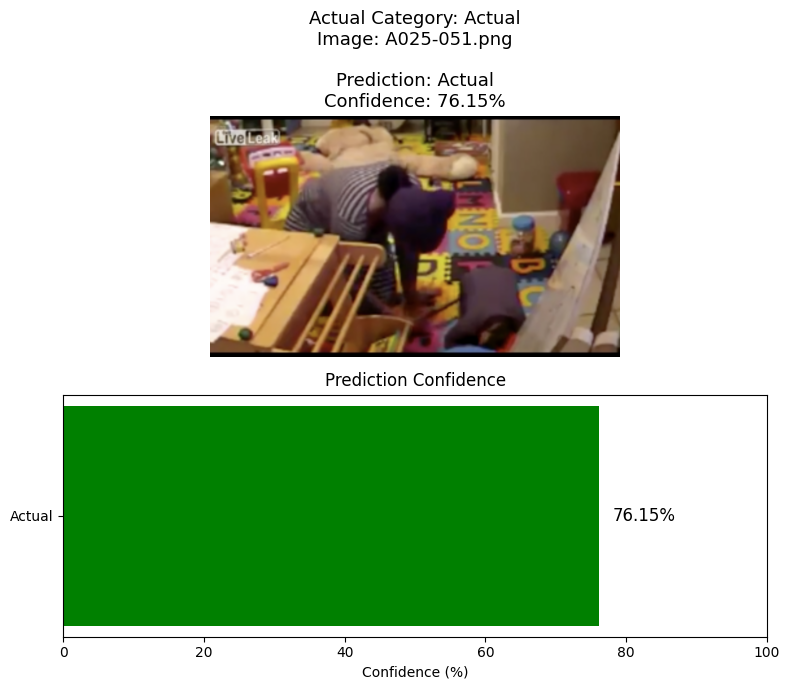


Edited Image


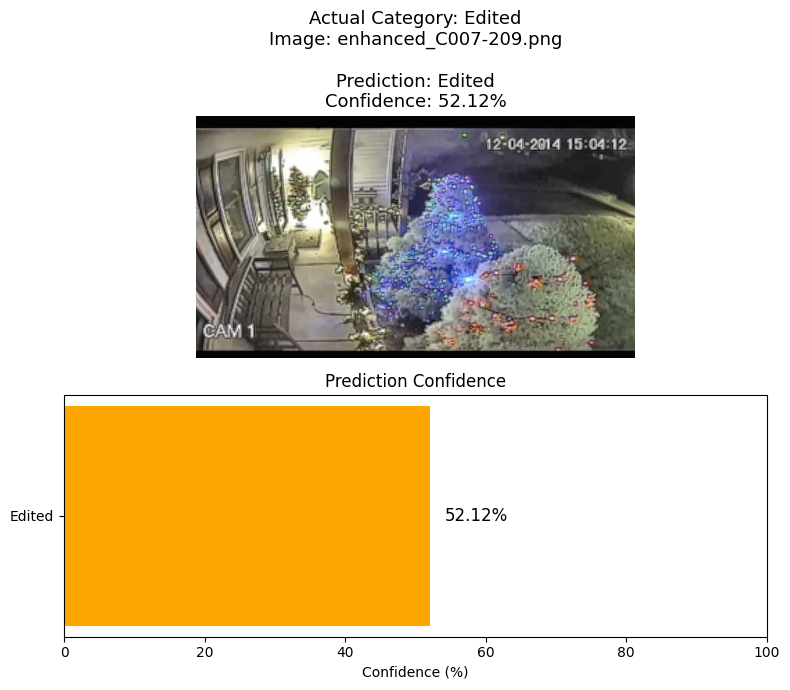


AI Generated Image


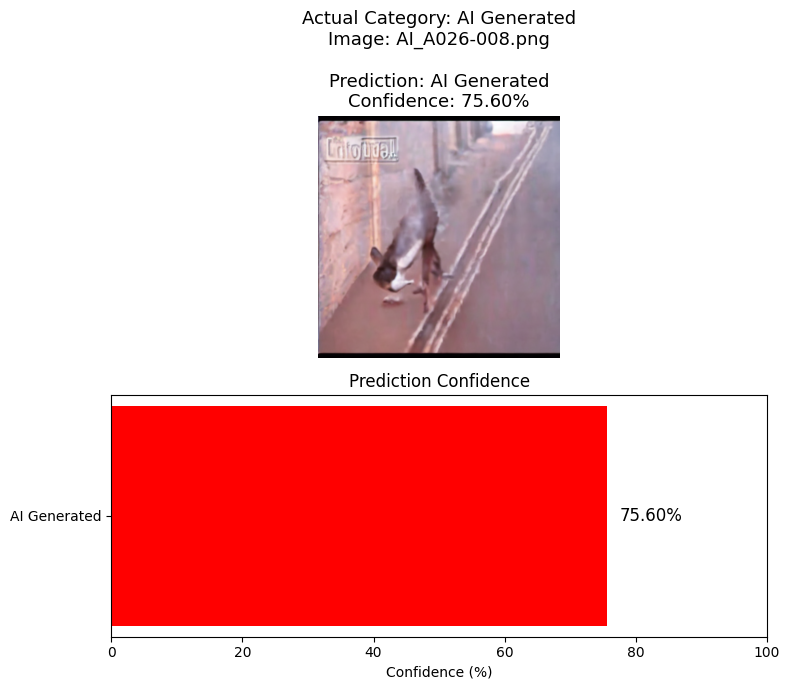

In [15]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


# ==============================
# Load Model
# ==============================

model_path = "/content/drive/MyDrive/image-authentication-project/models/model.h5"


model = tf.keras.models.load_model(
    model_path,
    compile=False
)


# Class order (IMPORTANT)
classes = [
    "Actual",
    "Edited",
    "AI Generated"
]


# ==============================
# Three Test Images Only
# ==============================

folders = {

    "Actual":
    "/content/drive/MyDrive/image-authentication-project/data/actual/A025-051.png",


    "Edited":
    "/content/drive/MyDrive/image-authentication-project/data/edited/enhanced_C007-209.png",


    "AI Generated":
    "/content/drive/MyDrive/image-authentication-project/data/ai_generated/AI_A026-008.png"

}



# ==============================
# Image Preprocessing
# ==============================

def preprocess_image(image_path):

    img = cv2.imread(
        image_path
    )


    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )


    img = cv2.resize(
        img,
        (224,224)
    )


    img = img / 255.0


    img = np.expand_dims(
        img,
        axis=0
    )


    return img




# ==============================
# Show Predictions
# ==============================

def show_all_predictions():


    for actual_class, image_path in folders.items():


        print(
            "\n=========================="
        )

        print(
            actual_class,
            "Image"
        )

        print(
            "=========================="
        )


        # Image name

        image_name = os.path.basename(
            image_path
        )


        # --------------------------
        # Prediction
        # --------------------------

        img = preprocess_image(
            image_path
        )


        prediction = model.predict(
            img,
            verbose=0
        )


        predicted_index = np.argmax(
            prediction
        )


        predicted_class = classes[
            predicted_index
        ]


        confidence = (
            prediction[0][predicted_index]
            * 100
        )



        # --------------------------
        # Read image for display
        # --------------------------

        display_img = cv2.imread(
            image_path
        )


        display_img = cv2.cvtColor(
            display_img,
            cv2.COLOR_BGR2RGB
        )



        # --------------------------
        # Prediction Colors
        # --------------------------

        if predicted_class == "Actual":

            color = "green"


        elif predicted_class == "Edited":

            color = "orange"


        else:

            color = "red"



        # --------------------------
        # Display
        # --------------------------

        plt.figure(
            figsize=(8,7)
        )



        # Image display

        plt.subplot(
            2,
            1,
            1
        )


        plt.imshow(
            display_img
        )


        plt.axis(
            "off"
        )


        plt.title(
            f"Actual Category: {actual_class}\n"
            f"Image: {image_name}\n\n"
            f"Prediction: {predicted_class}\n"
            f"Confidence: {confidence:.2f}%",
            fontsize=13
        )



        # Confidence bar

        plt.subplot(
            2,
            1,
            2
        )


        plt.barh(
            [predicted_class],
            [confidence],
            color=color,
            height=0.4
        )


        plt.xlim(
            0,
            100
        )


        plt.xlabel(
            "Confidence (%)"
        )


        plt.text(
            confidence + 2,
            0,
            f"{confidence:.2f}%",
            va="center",
            fontsize=12
        )


        plt.title(
            "Prediction Confidence"
        )


        plt.tight_layout()


        plt.show()



# ==============================
# Run
# ==============================

show_all_predictions()

Actual predictions: 1
Edited predictions: 1
AI Generated predictions: 1

Image: A025-051.png
Actual Category: Actual
Predicted Category: Actual
Confidence: 76.15%


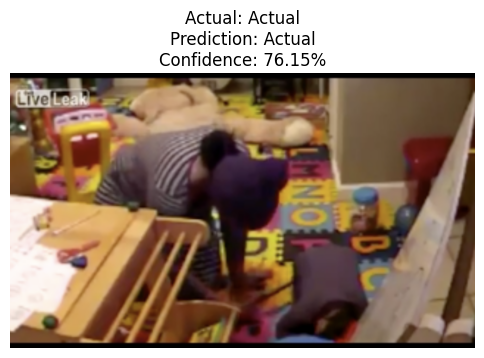


Image: enhanced_C007-209.png
Actual Category: Edited
Predicted Category: Edited
Confidence: 52.12%


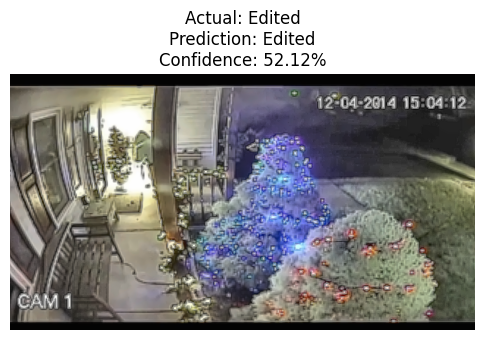


Image: AI_A026-008.png
Actual Category: AI Generated
Predicted Category: AI Generated
Confidence: 75.60%


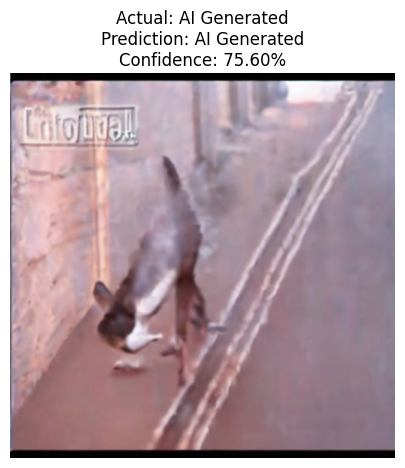

In [18]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


# ==================================
# Load Model
# ==================================

model_path = "/content/drive/MyDrive/image-authentication-project/models/model.h5"


model = tf.keras.models.load_model(
    model_path,
    compile=False
)


# Class names
# IMPORTANT: Must match your training order

classes = [
    "Actual",
    "Edited",
    "AI Generated"
]



# ==================================
# Three Test Images Only
# ==================================

folders = {

    "Actual":
    "/content/drive/MyDrive/image-authentication-project/data/actual/A025-051.png",


    "Edited":
    "/content/drive/MyDrive/image-authentication-project/data/edited/enhanced_C007-209.png",


    "AI Generated":
    "/content/drive/MyDrive/image-authentication-project/data/ai_generated/AI_A026-008.png"

}



# ==================================
# Store Prediction Results
# ==================================

prediction_results = {

    "Actual": [],

    "Edited": [],

    "AI Generated": []

}



# ==================================
# Prediction Function
# ==================================

def predict_single_image(image_path):


    img = cv2.imread(
        image_path
    )


    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )


    resized = cv2.resize(
        img,
        (224,224)
    )


    processed = resized / 255.0


    processed = np.expand_dims(
        processed,
        axis=0
    )


    prediction = model.predict(
        processed,
        verbose=0
    )


    class_index = np.argmax(
        prediction
    )


    confidence = (
        prediction[0][class_index]
        *100
    )


    predicted_class = classes[class_index]


    return (
        predicted_class,
        confidence,
        img
    )



# ==================================
# Run Prediction on 3 Images
# ==================================

for actual_class, image_path in folders.items():


    image_name = os.path.basename(
        image_path
    )


    predicted_class, confidence, img = predict_single_image(
        image_path
    )


    prediction_results[predicted_class].append({


        "name": image_name,


        "path": image_path,


        "confidence": confidence,


        "image": img,


        "actual_class": actual_class

    })



# ==================================
# Print Summary
# ==================================

print(
    "Actual predictions:",
    len(prediction_results["Actual"])
)


print(
    "Edited predictions:",
    len(prediction_results["Edited"])
)


print(
    "AI Generated predictions:",
    len(prediction_results["AI Generated"])
)




# ==================================
# Display Results
# ==================================

for predicted_category, results in prediction_results.items():


    for item in results:


        print("\n==========================")

        print(
            "Image:",
            item["name"]
        )

        print(
            "Actual Category:",
            item["actual_class"]
        )

        print(
            "Predicted Category:",
            predicted_category
        )

        print(
            "Confidence:",
            f"{item['confidence']:.2f}%"
        )


        # Display image

        plt.figure(
            figsize=(6,5)
        )


        plt.imshow(
            item["image"]
        )


        plt.axis(
            "off"
        )


        plt.title(
            f"Actual: {item['actual_class']}\n"
            f"Prediction: {predicted_category}\n"
            f"Confidence: {item['confidence']:.2f}%"
        )


        plt.show()

In [19]:
def display_prediction_category(
        category,
        color,
        images_per_page=25
):


    images = prediction_results[category]


    print(
        f"{category}: {len(images)} images"
    )


    pages = math.ceil(
        len(images)/images_per_page
    )


    for page in range(pages):


        batch = images[
            page*images_per_page:
            (page+1)*images_per_page
        ]


        plt.figure(
            figsize=(20,25)
        )


        for i,item in enumerate(batch):


            plt.subplot(
                5,
                5,
                i+1
            )


            plt.imshow(
                item["image"]
            )


            plt.axis(
                "off"
            )


            plt.title(
                f'{item["name"][:15]}\n'
                f'{item["confidence"]:.2f}%',
                fontsize=8
            )


        plt.suptitle(
            f"{category} Predictions - Page {page+1}",
            fontsize=20,
            color=color
        )


        plt.tight_layout()

        plt.show()

Actual: 1 images


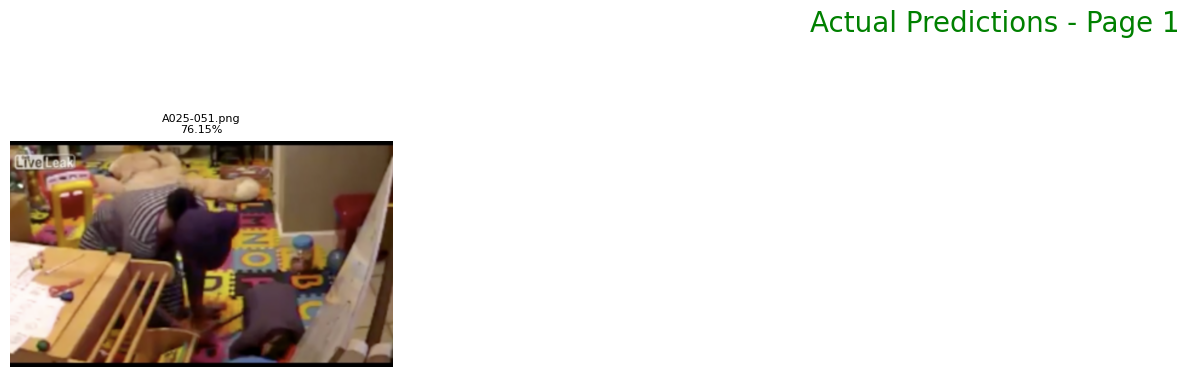

Edited: 1 images


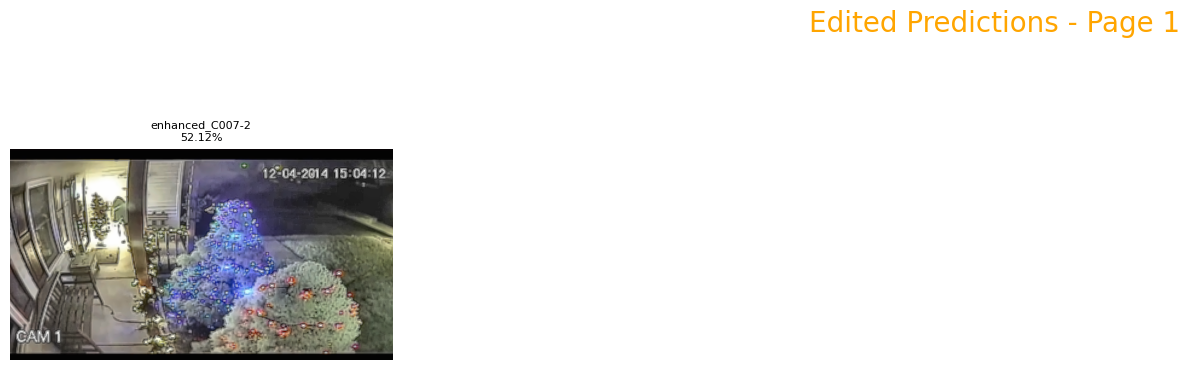

AI Generated: 1 images


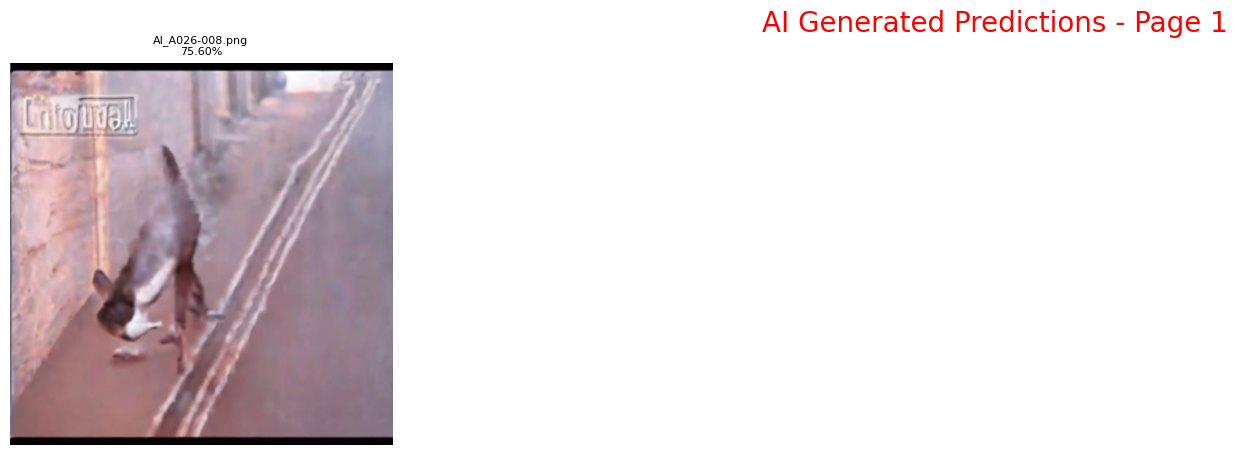

In [20]:
display_prediction_category(
    "Actual",
    "green"
)


display_prediction_category(
    "Edited",
    "orange"
)


display_prediction_category(
    "AI Generated",
    "red"
)

In [22]:
import pandas as pd
import os


results_list = []


# Run prediction on 3 images only

for actual_class, image_path in folders.items():


    image_name = os.path.basename(
        image_path
    )


    predicted_class, confidence, img = predict_single_image(
        image_path
    )


    results_list.append({

        "Image Name": image_name,

        "Original Category": actual_class,

        "Prediction": predicted_class,

        "Confidence (%)": round(confidence, 2)

    })



# Create dataframe

results_df = pd.DataFrame(
    results_list
)



# Display results

results_df

,Image Name,Original Category,Prediction,Confidence (%)
0,A025-051.png,Actual,Actual,76.150002
1,enhanced_C007-209.png,Edited,Edited,52.119999
2,AI_A026-008.png,AI Generated,AI Generated,75.599998


In [23]:
pd.set_option(
    "display.max_rows",
    600
)

results_df

,Image Name,Original Category,Prediction,Confidence (%)
0,A025-051.png,Actual,Actual,76.150002
1,enhanced_C007-209.png,Edited,Edited,52.119999
2,AI_A026-008.png,AI Generated,AI Generated,75.599998


In [24]:
results_df.to_csv(
    "prediction_results.csv",
    index=False
)

In [25]:
from google.colab import files

files.download(
    "prediction_results.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
results_df.to_csv(
    "/content/drive/MyDrive/image-authentication-project/results/prediction_results2.csv",
    index=False
)